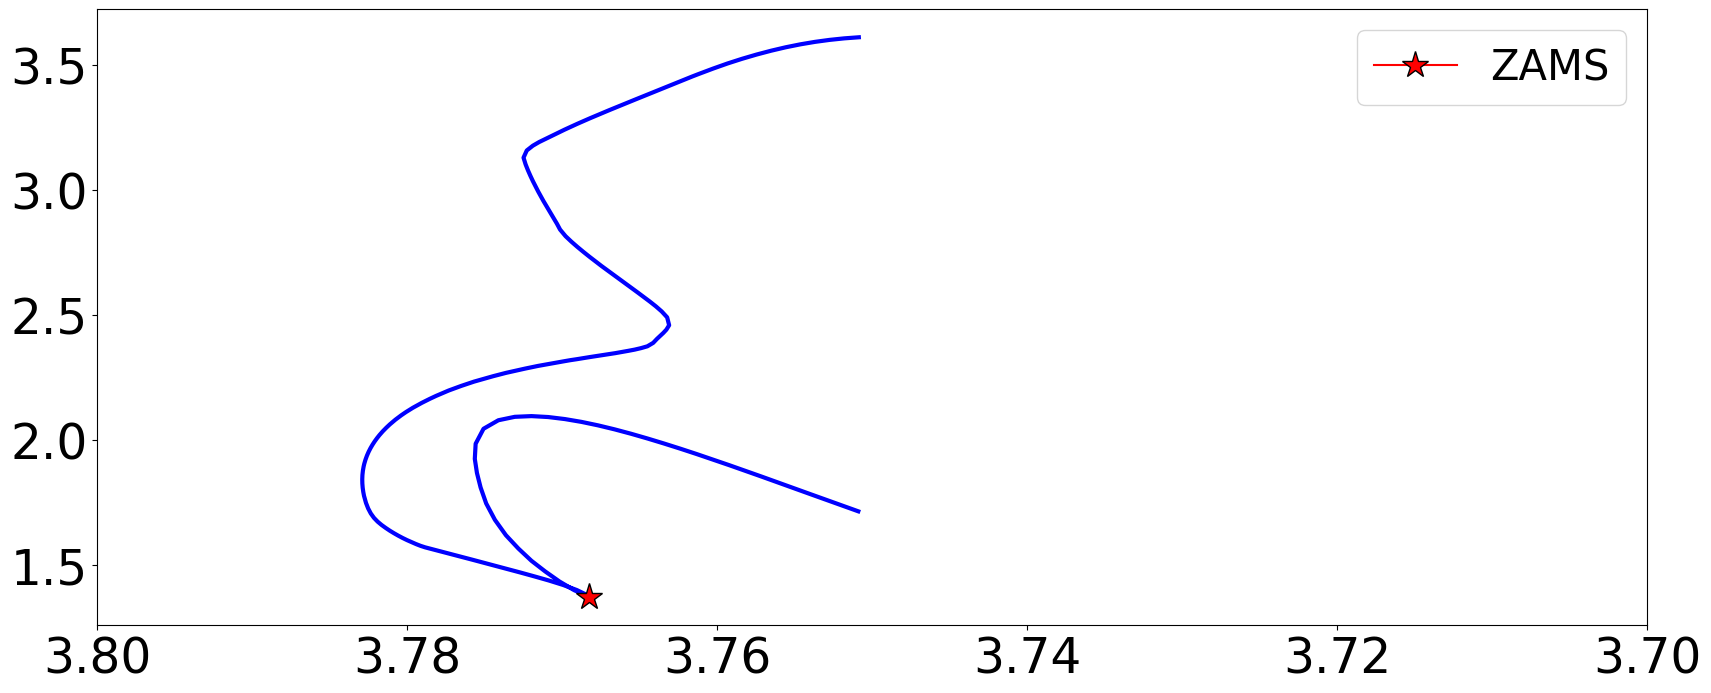

In [1]:
import kiauhoku as kh,matplotlib.pyplot as plt, numpy as np, pandas as pd

%matplotlib inline

grid = kh.load_interpolator('rocrit') #rocrit
# Stellar Grids: https://zenodo.org/records/11264222
# fastlaunch
# slowlaucnh
# rocrit
# mist - kernels dies
# yrec
# garstec - no Prot
# dartmouth - no Prot

# star = grid.get_star_eep((1.2295, 0.36,0,574)) # [mass, [Fe/H], [alpha/H], EEP], assuming solar alpha-abundance ([alpha/H]=0)
# print(star['Prot(days)'])
track = grid.get_track((1.2295, 0.36,0))# [mass, [Fe/H], [alpha/H]], assuming solar alpha-abundance ([alpha/H]=0)

plt.figure(figsize=(20,8))
index = np.argmax(track['logg'])
period_index = (track['Prot(days)'][index:]).reset_index(drop=True)
logg_index = (track['logg'][index:]).reset_index(drop=True)

# RG_period_mask = (period_index >=100) & (period_index <= 1000)
# MS_period_mask = (period_index >=20) & (period_index <= 30)

# Prot_new = np.array(period_index[RG_period_mask])
# Prot_MS = np.array(period_index[MS_period_mask])
# logg_new = np.array(logg_index[RG_period_mask])
# logg_MS = np.array(logg_index[MS_period_mask])
# ZAMS_idx = 19
log_temp_mask = (track['Log Teff(K)'] <3.8) & (track['Log Teff(K)']>3.75)
# print(track['Prot(days)'][np.argmax(track['logg'])])
# plt.semilogx(period_index,logg_index,'b',lw=3)
zams = np.argmin(track['L/Lsun'][log_temp_mask])
plt.plot(track['Log Teff(K)'][log_temp_mask],track['L/Lsun'][log_temp_mask],'b',lw=3)
plt.plot(track['Log Teff(K)'][log_temp_mask].iloc[zams],track['L/Lsun'][log_temp_mask].iloc[zams],
             'r',marker='*',markeredgecolor='k',markersize=20, label='ZAMS')
# print(np.argmin(track['L/Lsun'][log_temp_mask]))
# plt.semilogx(Prot_new,logg_new,'r',lw=3, label='Red Giant Branch')
# plt.semilogx(Prot_MS,logg_MS,'m',lw=3, label='Main Sequence Branch')
# plt.semilogx(Prot_MS[ZAMS_idx],logg_MS[ZAMS_idx],'orange', marker = '*', markeredgecolor='k',markersize=15, label='ZAMS')
# plt.axhline(3.0273,c='k', linestyle=":",linewidth=3.0)
# plt.axvline(826.047, c = 'k', linestyle=":",linewidth=3.0)
# plt.text(250,3.0,'826.047 d',fontsize=35)

# plt.ylim(4.5,2.5)
plt.xlim(3.8,3.7)
plt.tick_params(axis='both', which='major', labelsize=35)
# plt.xlabel(r'$\log(\text{Rotation Period/days})$',fontsize=35)
# plt.ylabel(r'logg (dex)',fontsize=35)
plt.legend(loc='upper right', fontsize=30)
# plt.savefig('Rot_period.png', dpi=100, facecolor='w', bbox_inches='tight')
# plt.close()

plot temp and luminosity ==> HR

In [2]:
df = pd.DataFrame(track)
df.columns

Index(['Age(Gyr)', 'L/Lsun', 'R/Rsun', 'Log Teff(K)', 'Mcz(Msun)', 'Rcz(Rsun)',
       'Xcen', 'Itot(cgs)', 'Icz(cgs)', 'Tau(cz)(sec)', 'He Core(Msun)',
       'Patm(cgs)', 'Mass(Msun)', 'Prot(days)', 'Icore(cgs)', 'Omega(core)',
       'Omega(env)', 'Jtot(cgs)', 'Jcore(cgs)', 'Jenv(cgs)', 'logg',
       'logT(cen)', 'logrho(cen)', 'Ycen', 'XC12cen', 'Xsurf', 'Ysurf',
       'Z/X(surf)', 'H lum (Lsun)', 'He lum (Lsun)'],
      dtype='str')

In [3]:
from IPython.display import display, Math

zams_L = df["L/Lsun"].values[np.argmin(track['L/Lsun'][log_temp_mask])]
zams_R = df["R/Rsun"].values[np.argmin(track['L/Lsun'][log_temp_mask])]
zams_M = df["Mass(Msun)"].values[np.argmin(track['L/Lsun'][log_temp_mask])]
semi_major_b = 0.25

display(Math(fr"$M_* = {zams_M:.3f}\,M_{{\odot}}$"))
display(Math(fr"$R_* = {zams_R:.3f}\,R_{{\odot}}$"))
display(Math(fr"$L_* = {zams_L:.3f}\,L_{{\odot}}$"))
display(Math(fr"I_b = {zams_L*(semi_major_b)**(-2):.3f}\,I_{{\oplus}}$"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>